In [46]:
# Original dataset: Kaggle 'Sleep Health and Lifestyle Dataset'
# All the data are synthetic per the creater of the dataset
# https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset

import pandas as pd
import numpy as np

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

In [47]:
# Descriptive statistics by gender

gender_result  = df.groupby('Gender')[['Quality of Sleep', 'Physical Activity Level', 'Stress Level','Heart Rate', 'Daily Steps']].mean().round(2)

gender_result = gender_result.rename(columns={
                                     'Quality of Sleep': 'Sleep_quality',
                                     'Physical Activity Level': 'Physical_activity_level',
                                     'Stress Level': 'Stress_level',
                                     'Heart Rate': 'Heart_rate',
                                     'Daily Steps': 'Daily_steps'})
gender_result

,Sleep_quality,Physical_activity_level,Stress_level,Heart_rate,Daily_steps
Gender,,,,,
Female,7.66,59.14,4.68,69.26,6840.54
Male,6.97,59.20,6.08,71.05,6793.65


In [50]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

X = df[['Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps']]
Y = df['Quality of Sleep']

lm.fit(X, Y)
print(f'The R-squared is: {lm.score(X, Y):.2f}')

The R-squared is: 0.85


In [51]:
import statsmodels.api as sm

X_with_const = sm.add_constant(X)

model = sm.OLS(Y, X_with_const)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       Quality of Sleep   R-squared:                       0.848
Model:                            OLS   Adj. R-squared:                  0.847
Method:                 Least Squares   F-statistic:                     515.9
Date:                Wed, 04 Mar 2026   Prob (F-statistic):          1.23e-149
Time:                        17:06:46   Log-Likelihood:                -244.77
No. Observations:                 374   AIC:                             499.5
Df Residuals:                     369   BIC:                             519.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

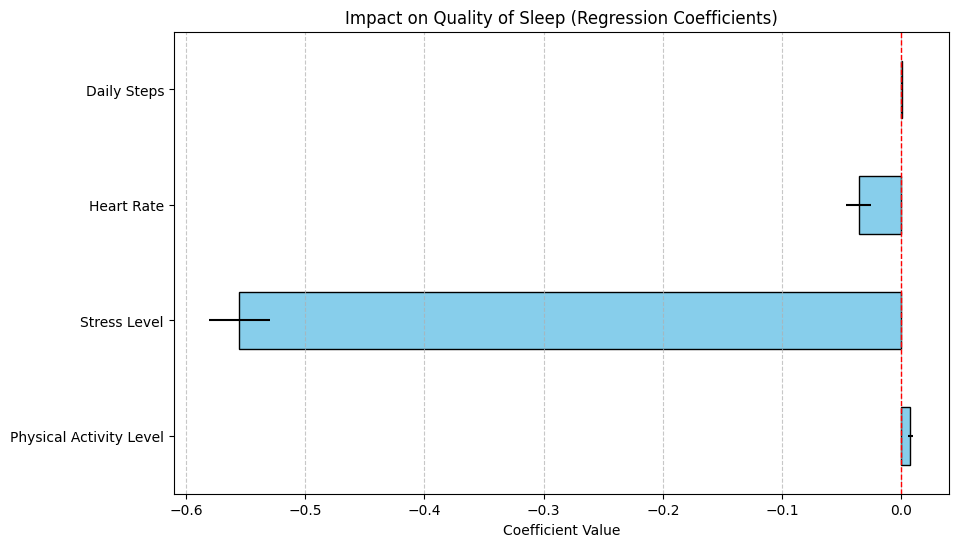

In [53]:
import matplotlib.pyplot as plt

params = results.params.drop('const')
errors = results.bse.drop('const')


plt.figure(figsize=(10, 6))
params.plot(kind='barh', xerr=errors, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.title('Impact on Quality of Sleep (Regression Coefficients)')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()